# Bootstrapping

In [1]:
# Importing packages!
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## What is Bootstrapping?

When performing an analysis, we may want to examine the distribution of certain statistics across our samples to infer things about our data. However, with a small sample size, it is difficult to come to conclusions about our analysis without collecting new samples. However, bootstrapping is the solution to this!

Bootstrapping is a statistical method that enables us to esteimate the sampling distribution of a dataset, thus allowing us to calculate statistics like mean, median, etc. on the data. It works by resampling data with replacement from our existing data, which allows us to perform analyses and make inferences without having to collect more samples.

## Steps for Bootstrapping
Below are the basic steps for performing bootstrapping.
1. Obtain a random sample from a population

2. Take a sample with replacement of the same sample size from the original sample

3. Calculate the statistic of interest from the resample

4. Repeat the resampling process until you have a distribution of resample statistics

## Performing Bootstrapping

We'll be using the blood lead dataset for performing a bootstrapping analysis. The blood lead dataset contains data from people exposed to lead. The first column of the dataset, `type`, indicates if each person was exposed (`exposed`) or not (`control`). The second column, `blood_lead`, contains the quantity of lead in the blood of each observed person.

Let's go through the steps of performing bootstrapping with the blood lead dataset! We will examine the distribution of the mean among control sample observations using bootstrapping.

In [3]:
# Reads in DataFrame
blood_lead = pd.read_csv("bloodlead.csv")
# Examines the DataFrame
blood_lead.head()

,type,blood_lead
0,exposed,38
1,exposed,23
2,exposed,41
3,exposed,18
4,exposed,37


**Step 1:** First, let's obtain our sample from the DataFrame. We'll extract the blood level values for both the exposed and the control groups and store them in two separate arrays. These will serve as our sample for the bootstrapping.

In [4]:
# Obtains the exposed group sample
exposed_bl = np.array(blood_lead[blood_lead['type'] == 'exposed']['blood_lead'])
# Obtains the control group sample
control_bl = np.array(blood_lead[blood_lead['type'] == 'control']['blood_lead'])

**Step 2:** We need to take a sample with replacement from our control group for this next step. The resample needs to be the same size as the original sample. To do this, we can use `np.random.choice()`.

In [5]:
# Resamples values with replacement from the control group
resampled_vls = np.random.choice(control_bl, len(control_bl))

**Step 3:** Next, we'll calculate our statistic of interest for our resampled values. We want to examine the mean of our blood lead values, so we can use `np.mean()` to determine that.

In [6]:
# Determines the mean of the resampled values
resampled_mean = np.mean(resampled_vls)
# Prints the mean
print(f'The mean of the resampled values is {resampled_mean}.')

The mean of the resampled values is 16.545454545454547.


**Step 4:** We'll repeat the bootstrapping process many times to determine the distribution of mean blood lead quantity for the control group. Let's perform the bootstrapping 10,000 times.

In [7]:
# Sets the number of bootstraps to perform
num_bootstraps = 10000
# Creates a list for storing means
meanlist = []

# Performs the bootstrap 10000 times
for resample in range(num_bootstraps):

    # Resamples the control group values
    resampled_vls = np.random.choice(control_bl, len(control_bl))
    # Calculates the mean
    fic_mean = np.mean(resampled_vls)
    # Adds the mean to the mean list
    meanlist.append(fic_mean)

Let's visualize our distribution of means using a histogram to see our bootstrapping data. We'll also plot a **confidence interval** for the means.

The confidence interval is the range where we are confident that the true value of our statistic (in this case the mean) lies. For this plot, we are calculating the 95% confidence level by selecting 2.5 and 97.5 as our percentile values. This means that we are 95% confident that the true mean is within that range of values.

Text(0.5, 1.0, 'Distribution of Blood Lead Means')

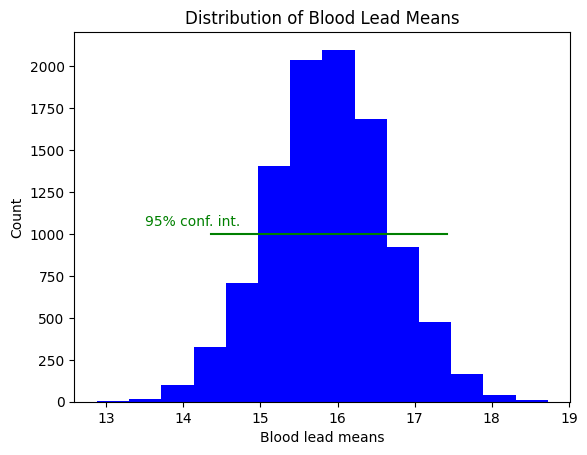

In [25]:
# Creates a figure for plotting
fig, ax = plt.subplots()

# Plots a histogram of means
ax.hist(meanlist, bins = 14, color = 'b')

# Plots the confidence interval
conf_interval = np.percentile(meanlist, [2.5, 97.5])
ax.plot([conf_interval[0], conf_interval[1]], [1000, 1000], 'g')
ax.text(13.5, 1050, '95% conf. int.', c = 'g')

# Labels the plot
ax.set_xlabel('Blood lead means')
ax.set_ylabel('Count')
ax.set_title('Distribution of Blood Lead Means')

Based on this mean distribution plot, it looks like the true blood lead mean is between around 14.5 to 17.5.